# Gaussian Filtering

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline


## (a) Compute Normalized 5×5 Gaussian Kernel

In [3]:
def compute_gaussian_kernel(size, sigma):
    # Create coordinate arrays
    center = size // 2
    x, y = np.meshgrid(np.arange(size) - center, np.arange(size) - center)
    
    # Compute Gaussian values
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # Normalize so that sum equals 1
    kernel = kernel / kernel.sum()
    
    return kernel

# Compute 5×5 Gaussian kernel with σ = 2
sigma = 2
kernel_5x5 = compute_gaussian_kernel(5, sigma)

print(f"5×5 Gaussian Kernel (sigma = {sigma}):")
print(kernel_5x5)
print(f"\nSum of kernel values: {kernel_5x5.sum():.10f}")
print(f"Center value: {kernel_5x5[2, 2]:.6f}")


5×5 Gaussian Kernel (sigma = 2):
[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]

Sum of kernel values: 1.0000000000
Center value: 0.063191


## (b) Visualize 51×51 Gaussian Kernel as 3D Surface Plot

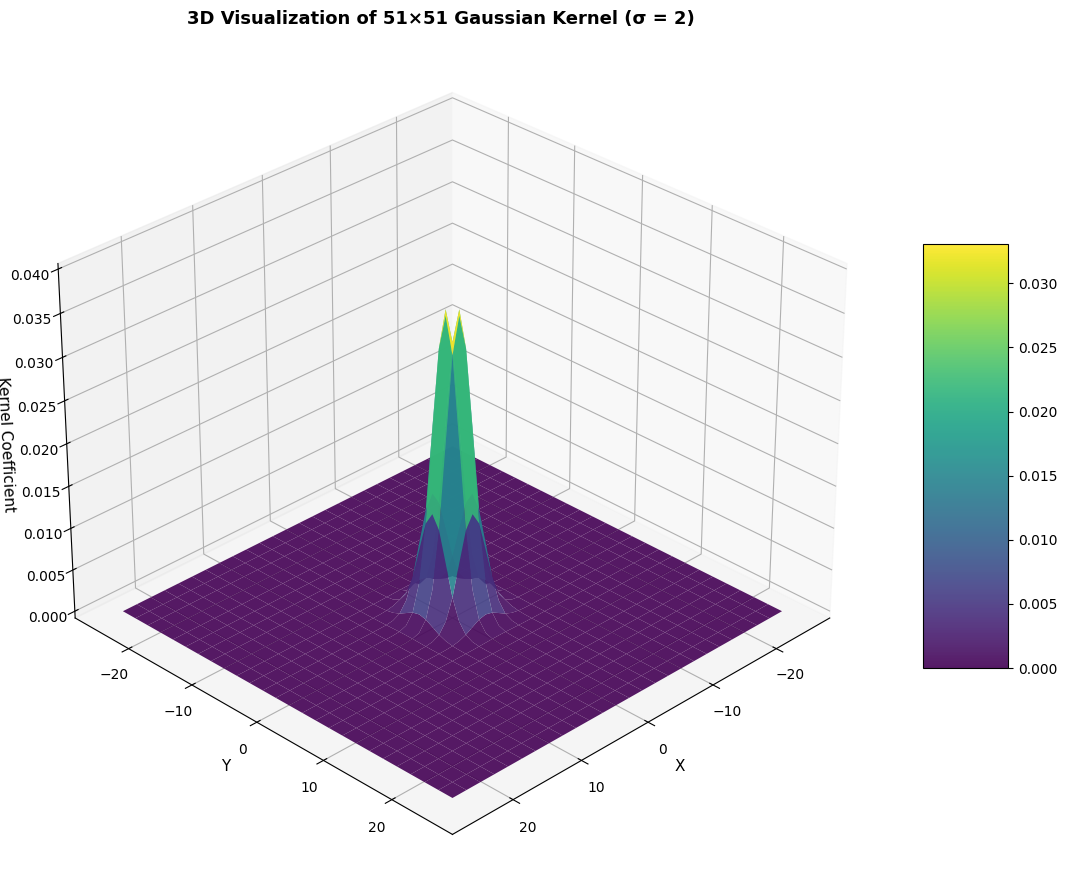

51×51 Gaussian Kernel Statistics:
  Max value: 0.03978874
  Min value: 0.00000000
  Sum: 1.0000000000


In [4]:
# Compute 51×51 Gaussian kernel
kernel_51x51 = compute_gaussian_kernel(51, sigma)

# Create coordinate grids for plotting
center = 51 // 2
x = np.arange(51) - center
y = np.arange(51) - center
X, Y = np.meshgrid(x, y)

# Create 3D surface plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(X, Y, kernel_51x51, cmap='viridis', edgecolor='none', alpha=0.9)

# Customize plot
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_zlabel('Kernel Coefficient', fontsize=11)
ax.set_title(f'3D Visualization of 51×51 Gaussian Kernel (σ = {sigma})', fontsize=13, fontweight='bold')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Set viewing angle
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

print(f"51×51 Gaussian Kernel Statistics:")
print(f"  Max value: {kernel_51x51.max():.8f}")
print(f"  Min value: {kernel_51x51.min():.8f}")
print(f"  Sum: {kernel_51x51.sum():.10f}")


## (c) Apply Gaussian Smoothing with Manual Kernel

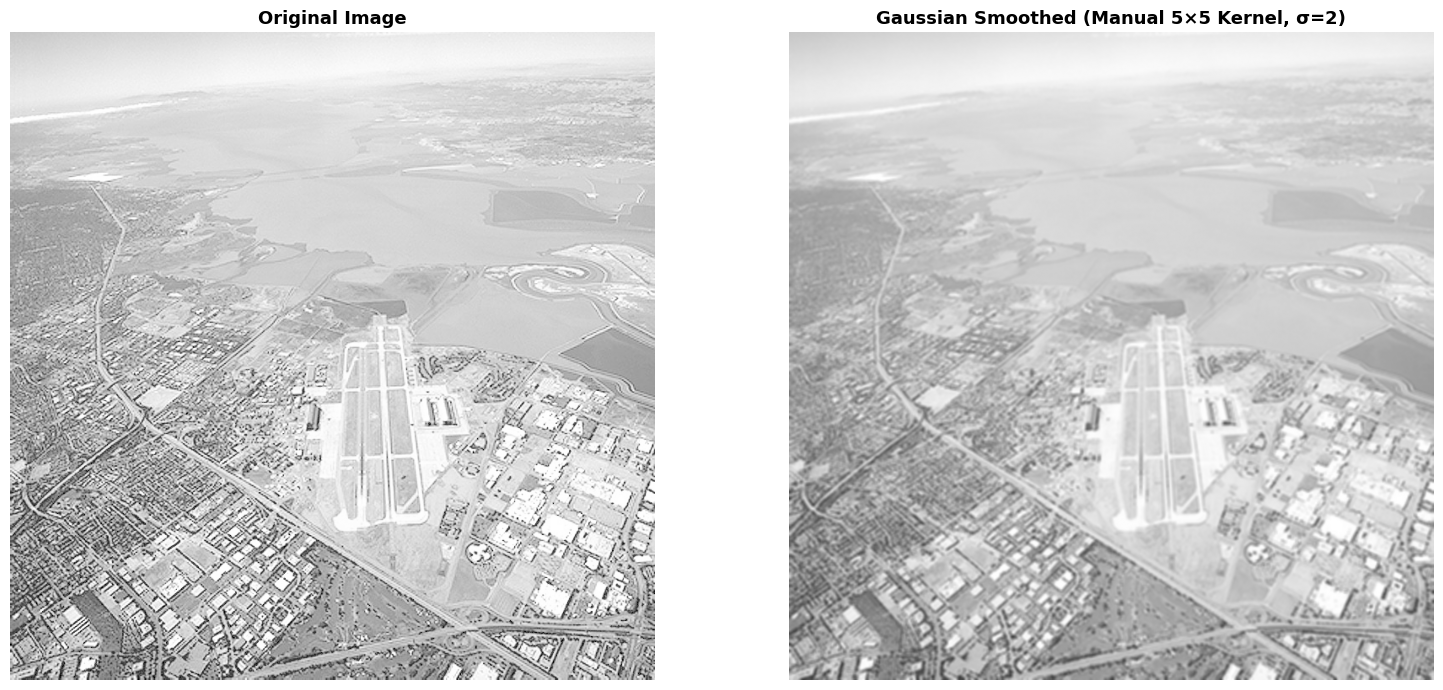

In [5]:
# Load a grayscale image
img = cv2.imread('runway.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found")

# Apply Gaussian smoothing using manually computed kernel
img_manual_gaussian = cv2.filter2D(img, -1, kernel_5x5)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_manual_gaussian, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Gaussian Smoothed (Manual 5×5 Kernel, σ={sigma})', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## (d) Apply Gaussian Smoothing with OpenCV GaussianBlur()

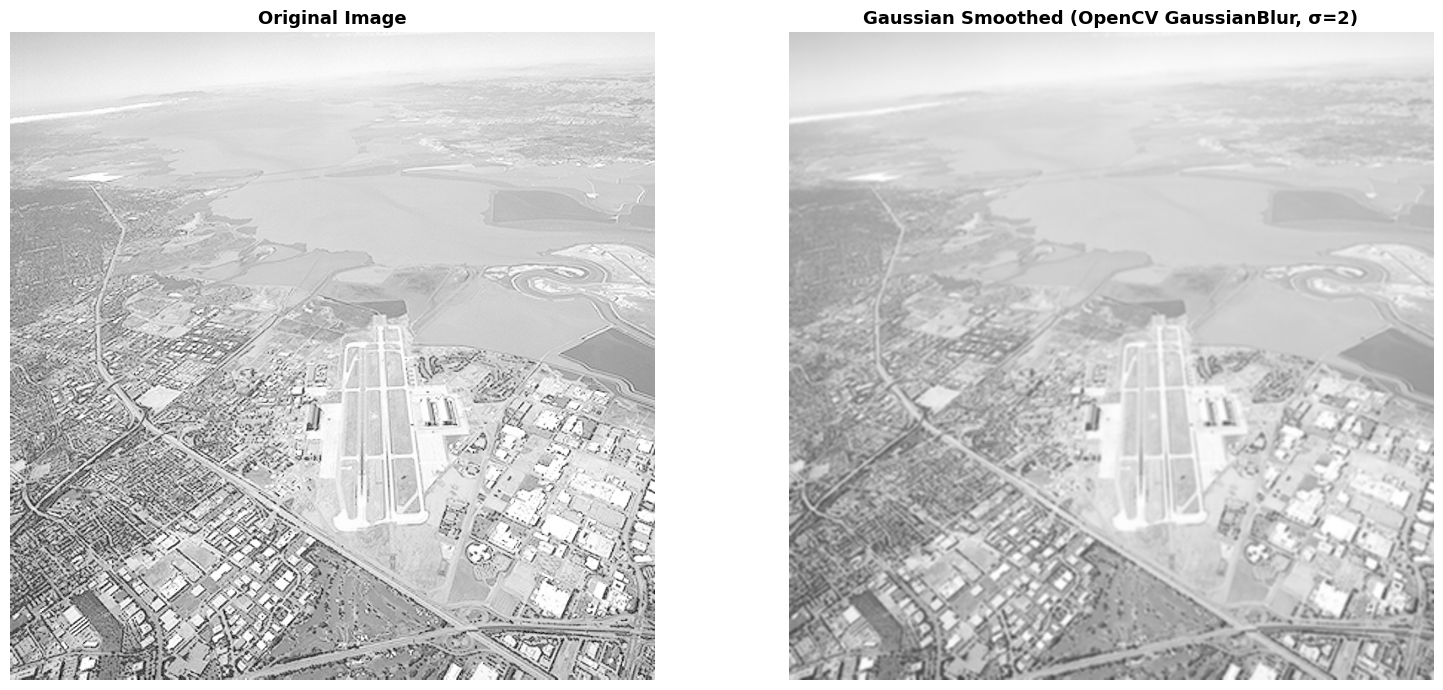

In [6]:
# Apply Gaussian smoothing using OpenCV's GaussianBlur()
# Kernel size must be odd, sigmaX is the standard deviation in X direction
img_opencv_gaussian = cv2.GaussianBlur(img, (5, 5), sigma)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_opencv_gaussian, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Gaussian Smoothed (OpenCV GaussianBlur, σ={sigma})', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Comparison: Manual vs OpenCV GaussianBlur

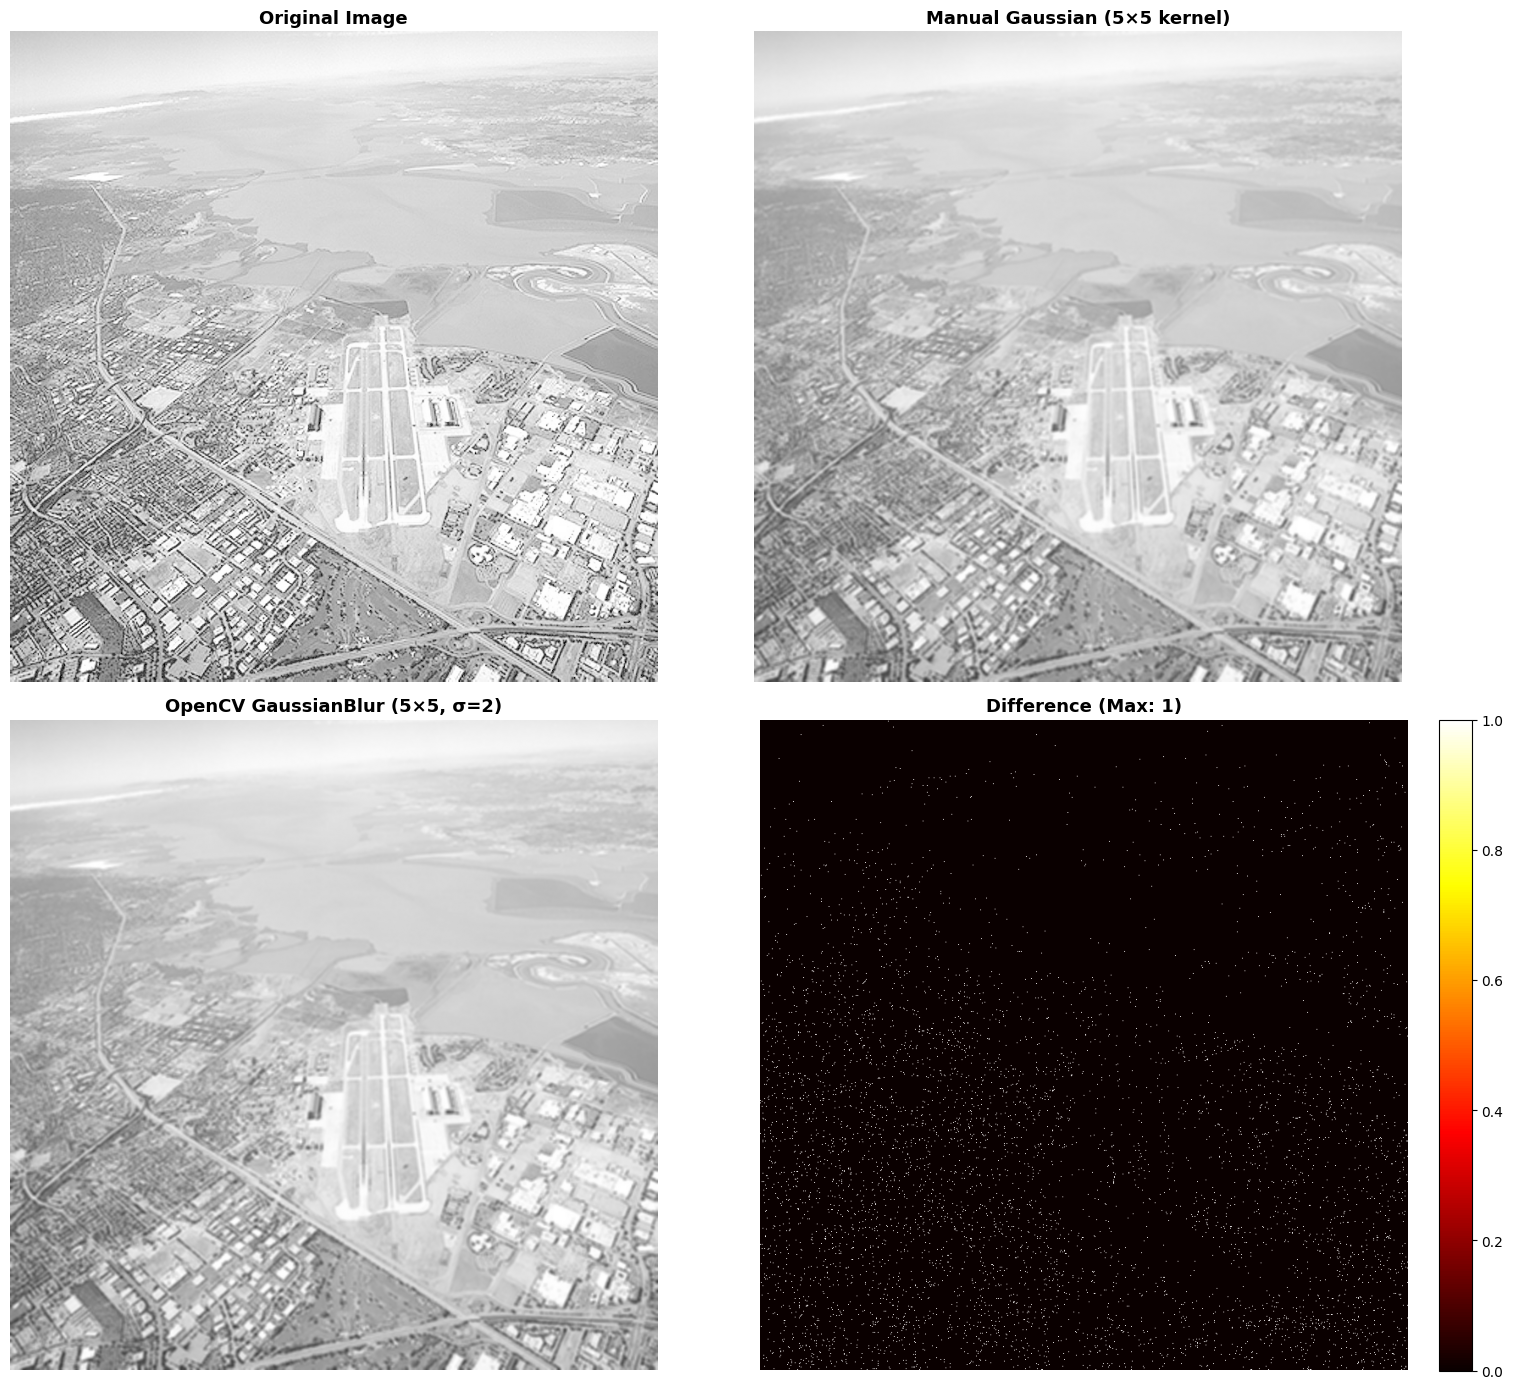

COMPARISON RESULTS:
Max difference: 1
Mean difference: 0.0097
Identical pixels: 99.03%


In [8]:
# Compare all three images
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_manual_gaussian, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Manual Gaussian (5×5 kernel)', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_opencv_gaussian, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('OpenCV GaussianBlur (5×5, σ=2)', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

# Compute difference
difference = np.abs(img_manual_gaussian.astype(int) - img_opencv_gaussian.astype(int))
axes[1, 1].imshow(difference, cmap='hot', vmin=0, vmax=difference.max())
axes[1, 1].set_title(f'Difference (Max: {difference.max()})', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("COMPARISON RESULTS:")
print(f"Max difference: {difference.max()}")
print(f"Mean difference: {difference.mean():.4f}")
print(f"Identical pixels: {np.sum(difference == 0) / difference.size * 100:.2f}%")